In [90]:
import sys
sys.path.insert(0, '..')

In [91]:
# Basic imports
import jax.numpy as np
import jax.random as jr
import jax.scipy as jsp
import jax
import numpy

jax.config.update("jax_enable_x64", True)


# Optimisation imports
import zodiax as zdx
import optax
import optimistix as optx

# dLux imports
import dLux as dl
import dLux.utils as dlu

# Visualisation imports
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import matplotlib

%matplotlib inline
plt.rcParams['image.cmap'] = 'inferno'
plt.rcParams["font.family"] = "serif"
plt.rcParams["image.origin"] = 'lower'
plt.rcParams['figure.dpi'] = 72
plt.rcParams["font.size"] = 24

from detectors import *
from apertures import *
from models import *
from fisher import *
from stats import posterior
from fitting import *
from plotting import *
from spectra import *

import jax.tree_util as jtu
import interpax as ipx

def set_array(pytree):
    dtype = np.float64 if jax.config.x64_enabled else np.float32
    floats, other = eqx.partition(pytree, eqx.is_inexact_array_like)
    floats = jtu.tree_map(lambda x: np.array(x, dtype=dtype), floats)
    return eqx.combine(floats, other)

In [92]:
wid = 64
oversample = 4

nwavels = 5#13#6
npoly=1#10#2

n_zernikes = 20#30#12

optics = NICMOSSecondaryFresnelOptics(512, wid, oversample, mag=3.3, defocus=0., despace=0., n_zernikes = n_zernikes)

detector = NICMOSDetector(oversample, wid)

spectrum_basis = np.ones((nwavels, npoly))

In [93]:
data = '../data/MAST_2025-06-26T06_57_47.174Z/HST/'

files = """
na2m01k7q_cal.fits
na2m01k8q_cal.fits
na2m01k9q_cal.fits
na2m01kaq_cal.fits
na2m01kbq_cal.fits
na2m01kcq_cal.fits
na2m01kdq_cal.fits
na2m01keq_cal.fits
na2m01kfq_cal.fits
na2m01kgq_cal.fits
na2m01kiq_cal.fits
na2m01kjq_cal.fits
na2m01kkq_cal.fits
na2m01klq_cal.fits
na2m01kmq_cal.fits
na2m01knq_cal.fits
na2m01koq_cal.fits
na2m01kpq_cal.fits
na2m01kqq_cal.fits
na2m01krq_cal.fits
na2m01ksq_cal.fits
na2m01ktq_cal.fits
na2m01kuq_cal.fits
na2m01kvq_cal.fits
na2m01kwq_cal.fits
na2m01kyq_cal.fits
na2m01kzq_cal.fits
na2m01l0q_cal.fits
na2m01l1q_cal.fits
na2m01l2q_cal.fits
na2m01l3q_cal.fits
na2m01l4q_cal.fits
na2m01l5q_cal.fits
na2m01l6q_cal.fits
na2m01l7q_cal.fits
na2m01l8q_cal.fits
na2m01l9q_cal.fits
na2m01laq_cal.fits
na2m01lbq_cal.fits
na2m01lcq_cal.fits
na2m01leq_cal.fits
na2m01lfq_cal.fits
na2m01lgq_cal.fits
na2m01lhq_cal.fits
na2m01liq_cal.fits
na2m01ljq_cal.fits
na2m01lkq_cal.fits
na2m01llq_cal.fits
na2m01lmq_cal.fits
na2m01lnq_cal.fits
na2m01loq_cal.fits
na2m01lpq_cal.fits
na2m01lqq_cal.fits
na2m01lrq_cal.fits
na2m01lsq_cal.fits
na2m01luq_cal.fits
na2m01lvq_cal.fits
na2m01lwq_cal.fits
na2m01lxq_cal.fits
na2m01lyq_cal.fits
na2m01lzq_cal.fits
na2m01m0q_cal.fits
na2m01m1q_cal.fits
na2m01m2q_cal.fits
na2m01m3q_cal.fits
na2m01m4q_cal.fits
na2m01m5q_cal.fits
na2m01m6q_cal.fits
na2m01m7q_cal.fits
na2m01m8q_cal.fits
na2m01maq_cal.fits
na2m01mbq_cal.fits
na2m01mcq_cal.fits
na2m01mdq_cal.fits
na2m01meq_cal.fits
na2m01mfq_cal.fits
na2m01mgq_cal.fits
na2m01mhq_cal.fits
na2m01miq_cal.fits
na2m01mjq_cal.fits
na2m01mkq_cal.fits
na2m01mlq_cal.fits
na2m01mmq_cal.fits
na2m01mnq_cal.fits
na2m01moq_cal.fits
na2m01mqq_cal.fits
na2m01mrq_cal.fits
na2m01msq_cal.fits
na2m01mtq_cal.fits
na2m01muq_cal.fits
na2m01mvq_cal.fits
na2m01mwq_cal.fits
na2m01mxq_cal.fits
na2m01myq_cal.fits
na2m01mzq_cal.fits
na2m01n0q_cal.fits
na2m01n1q_cal.fits
na2m01n2q_cal.fits
na2m01n3q_cal.fits
na2m01n4q_cal.fits
""".split()[::10][:1]
#exposures_raw = [exposure_from_file(data + file, SinglePointFit(CombinedPolySpectrum, nwavels), crop=wid, extra_bad=extra_bad) for file in files]

spectrum_basis = np.ones((1, 3))

exposures_raw = [exposure_from_file(data + file, SinglePointFit(spectrum_basis, "F187N", time_series=True), crop=wid) for file in files]


exposures_single = []
for exp in exposures_raw:
    if exp.data.shape == (wid, wid):
        exposures_single.append(exp)

Version 4.4.1
106 91


/Users/haydengreer/PhD/hst/hubble/notebooks/../models.py:176: UserWarning: A JAX array is being set as static! This can result in unexpected behavior and is usually a mistake to do.
  return Exposure(filename, name, filter, data, err_with_poisson, bad_with_poisson, fit, mjd, exptime, wcs, pam)


In [94]:
for e in exposures_single:
    print(e.mjd)#*86400)
    print(e.target)
    print(e.filter)
    print(e.exptime)

54571.66436884
HD189733
F187N
3.996392


In [95]:
params = {
    #"fluxes": {},
    "positions": {},
    "spectrum": {},
    "aberrations": {},

    #"rot": 0.,

    "cold_mask_shift": {},
    "cold_mask_rot": {},
    "cold_mask_scale": {},
    "cold_mask_shear": {},
    "primary_scale": {},
    "primary_rot": {},
    "primary_shear": {},
    "outer_radius": 1.2*0.955,
    "secondary_radius": 0.372*1.2,
    "spider_width": 0.077*1.2,

    "softening": 10.,
    "bias": {},
    "jitter": {},

    "defocus": {},
    "despace": {},
    "mag": 3.3,
    "quadrature": {},
}

positions = [[0.,0.,],[0.,0.,],[0.,0.,],[0.,0.,]]#[[0.43251792, 0.33013815],[ 0.49417186, -0.5629123 ]]


for idx, exp in enumerate(exposures_single):
    params["positions"][exp.fit.get_key(exp, "positions")] = np.asarray([0.,0.])
    params["spectrum"][exp.fit.get_key(exp, "spectrum")] = (np.nansum(exp.data)/nwavels)

    params["aberrations"][exp.fit.get_key(exp, "aberrations")] = np.zeros(n_zernikes)
    # np.array([ 12.66013155,  -3.74036652, -20.8438651 ,   1.09282138,
    #        3.48634449,  -8.31898117,  22.48192372,   1.41053358,
    #       -2.31421321,   4.85990522,  -6.0902642 ,  14.10482417,
    #       -9.43575842,   1.14218497,   1.77468617,   1.81254211,
    #       -2.2649688 ,  -0.45356718,  -3.61981819,   0.74366754])

    params["cold_mask_shift"][exp.fit.get_key(exp, "cold_mask_shift")] = np.asarray([8.8,8.])
    params["cold_mask_rot"][exp.fit.get_key(exp, "cold_mask_rot")] = -45.
    params["cold_mask_scale"][exp.fit.get_key(exp, "cold_mask_scale")] = np.asarray([1.,1.])
    params["cold_mask_shear"][exp.fit.get_key(exp, "cold_mask_shear")] = np.asarray([0.,0.])
    params["primary_rot"][exp.fit.get_key(exp, "primary_rot")] = -45. + 90. 
    params["primary_scale"][exp.fit.get_key(exp, "primary_scale")] = np.asarray([1.,1.])
    params["primary_shear"][exp.fit.get_key(exp, "primary_shear")] = np.asarray([0.,0.])
    params["defocus"][exp.fit.get_key(exp, "defocus")] = 0.233
    params["despace"][exp.fit.get_key(exp, "despace")] = 0.#-5.#0.
    

    params["bias"][exp.fit.get_key(exp, "bias")] = 2.85
    params["jitter"][exp.fit.get_key(exp, "jitter")] = 7/43*oversample

    params["quadrature"][exp.fit.get_key(exp, "quadrature")] = np.array(0.)


model_single = set_array(NICMOSModel(exposures_single, params, optics, detector))
#model_binary = set_array(NICMOSModel(exposures_binary, params, optics, detector))


params = ModelParams(params)

10.16354013078516


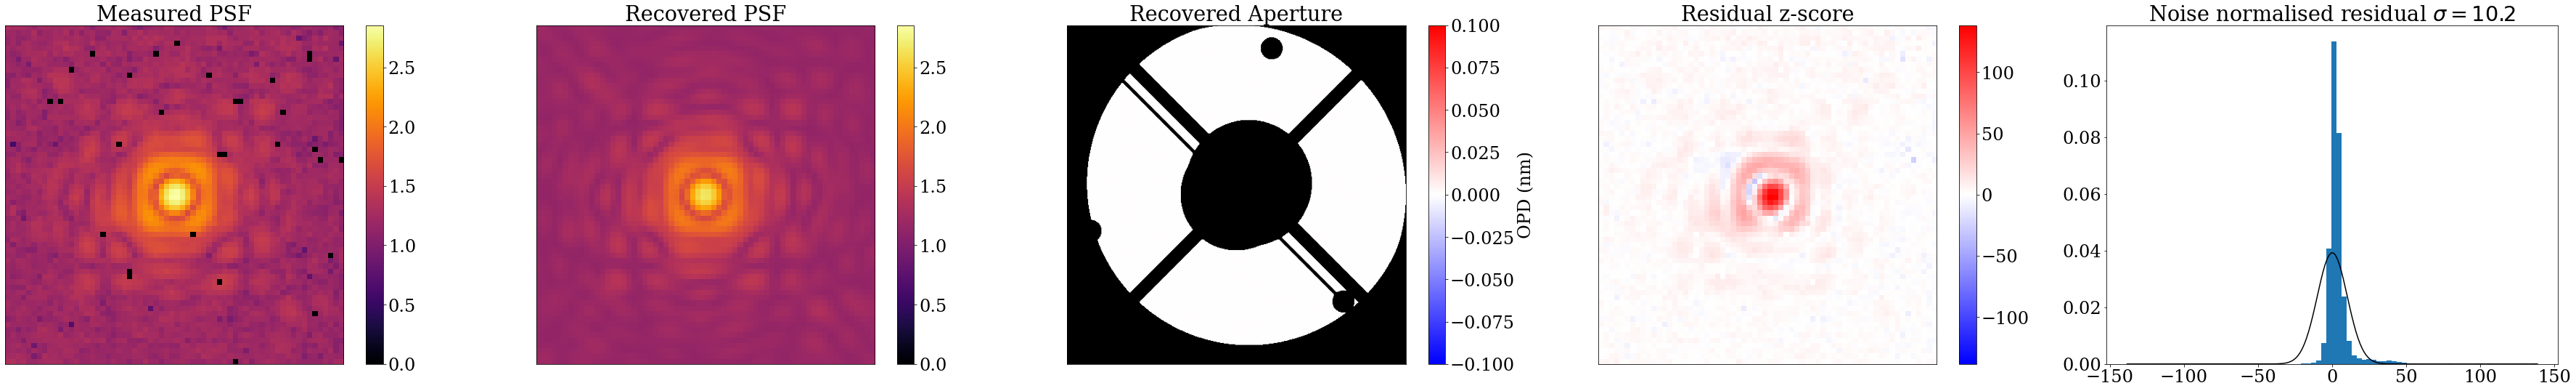

In [96]:
plot_comparison(model_single, params, exposures_single)

In [97]:
def sgd(lr, delay, momentum=0.5):
    return optax.sgd(zdx.optimisation.delay(lr, delay), momentum=momentum)


g = 5e-2

things = {
    "positions": sgd(g*2.5, 0),
    "spectrum": sgd(g*3, 10),
    "cold_mask_shift": sgd(g*2, 30),
    
    "bias": sgd(g*3, 20),
    "aberrations": sgd(g*2, 70),
    #"jitter": opt(g*1, 120),

    "despace": sgd(g*10, 50),
    "mag": sgd(g*3, 100),

    # "cold_mask_shear": sgd(g*2, 100),

    "quadrature": sgd(g*20, 400)
}

things_start = {
    "positions": sgd(g*5, 0),
}

groups = list(things.keys())

In [98]:
orig_params = params.params
opt_params = set_array({k:orig_params[k] for k in orig_params if k in things_start})

In [99]:
losses, params_history = optimise_new(opt_params, model_single, exposures_single, things_start, 10)

[2.44885446e-06 2.72549332e-06]


  0%|          | 0/10 [00:00<?, ?it/s]

9.727889584019897


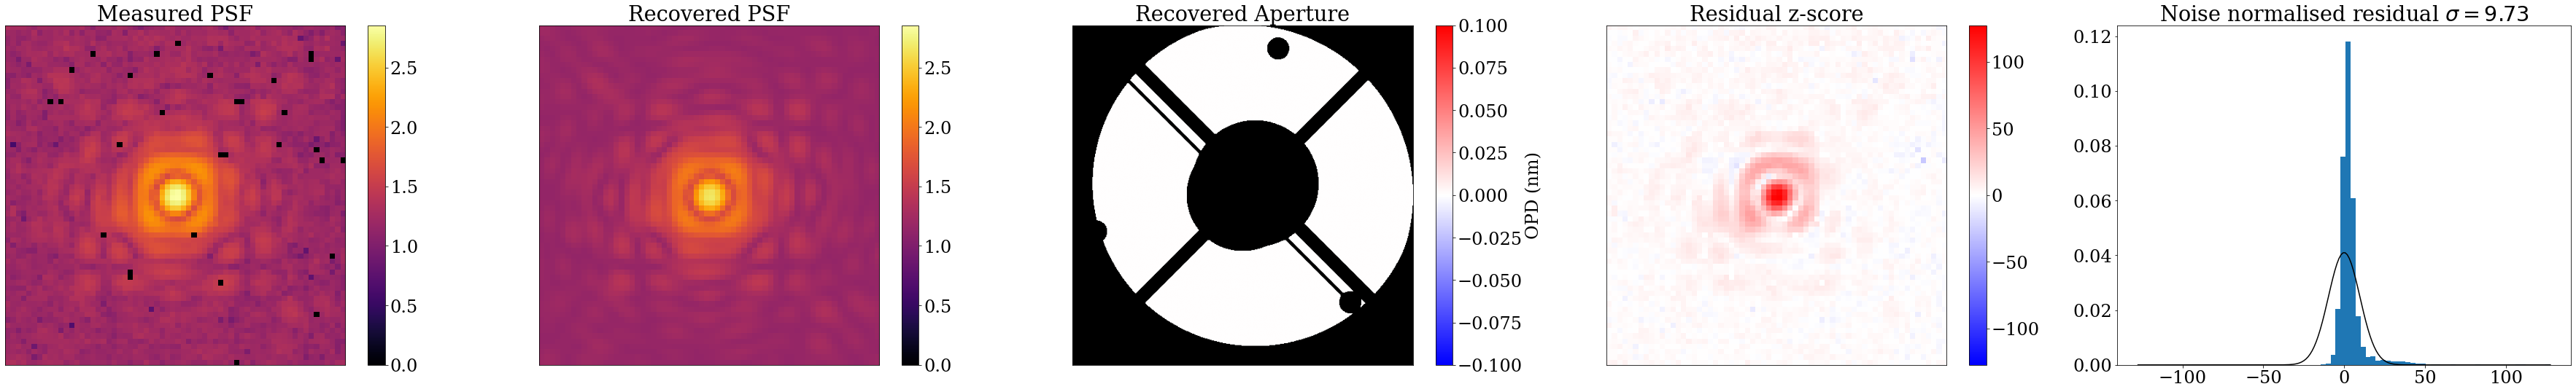

In [100]:
plot_comparison(model_single, ModelParams(params_history[-1]), exposures_single)

In [101]:
orig_params = params.params | params_history[-1]
opt_params = set_array({k:orig_params[k] for k in orig_params if k in things})

In [102]:
losses, params_history = optimise_new(opt_params, model_single, exposures_single, things, 500, nbatches=len(exposures_single))

[6.67900809e-02 6.68614701e-02 5.30937754e-02 5.27692658e-02
 3.82441384e-02 3.72367203e-02 1.19791958e-01 5.25225692e-02
 8.08009824e-02 7.22016221e-02 5.25425108e-02 6.23632541e-02
 5.97035963e-02 3.62577117e-02 3.66345709e-02 6.75146475e-02
 6.97671447e-02 5.22155993e-02 5.45949791e-02 3.66752282e-02
 1.20320964e-04 4.36823513e-05 4.18922233e-05 1.39796427e-03
 5.33194048e-07 2.79436632e-06 2.88404888e-06 2.07313433e-07
 8.45296193e+02]


  0%|          | 0/500 [00:00<?, ?it/s]

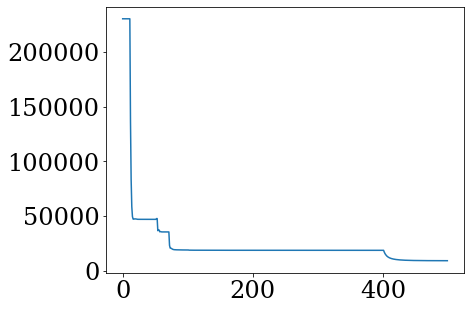

In [103]:
plt.plot(losses[:])

8
1.0689006670490198


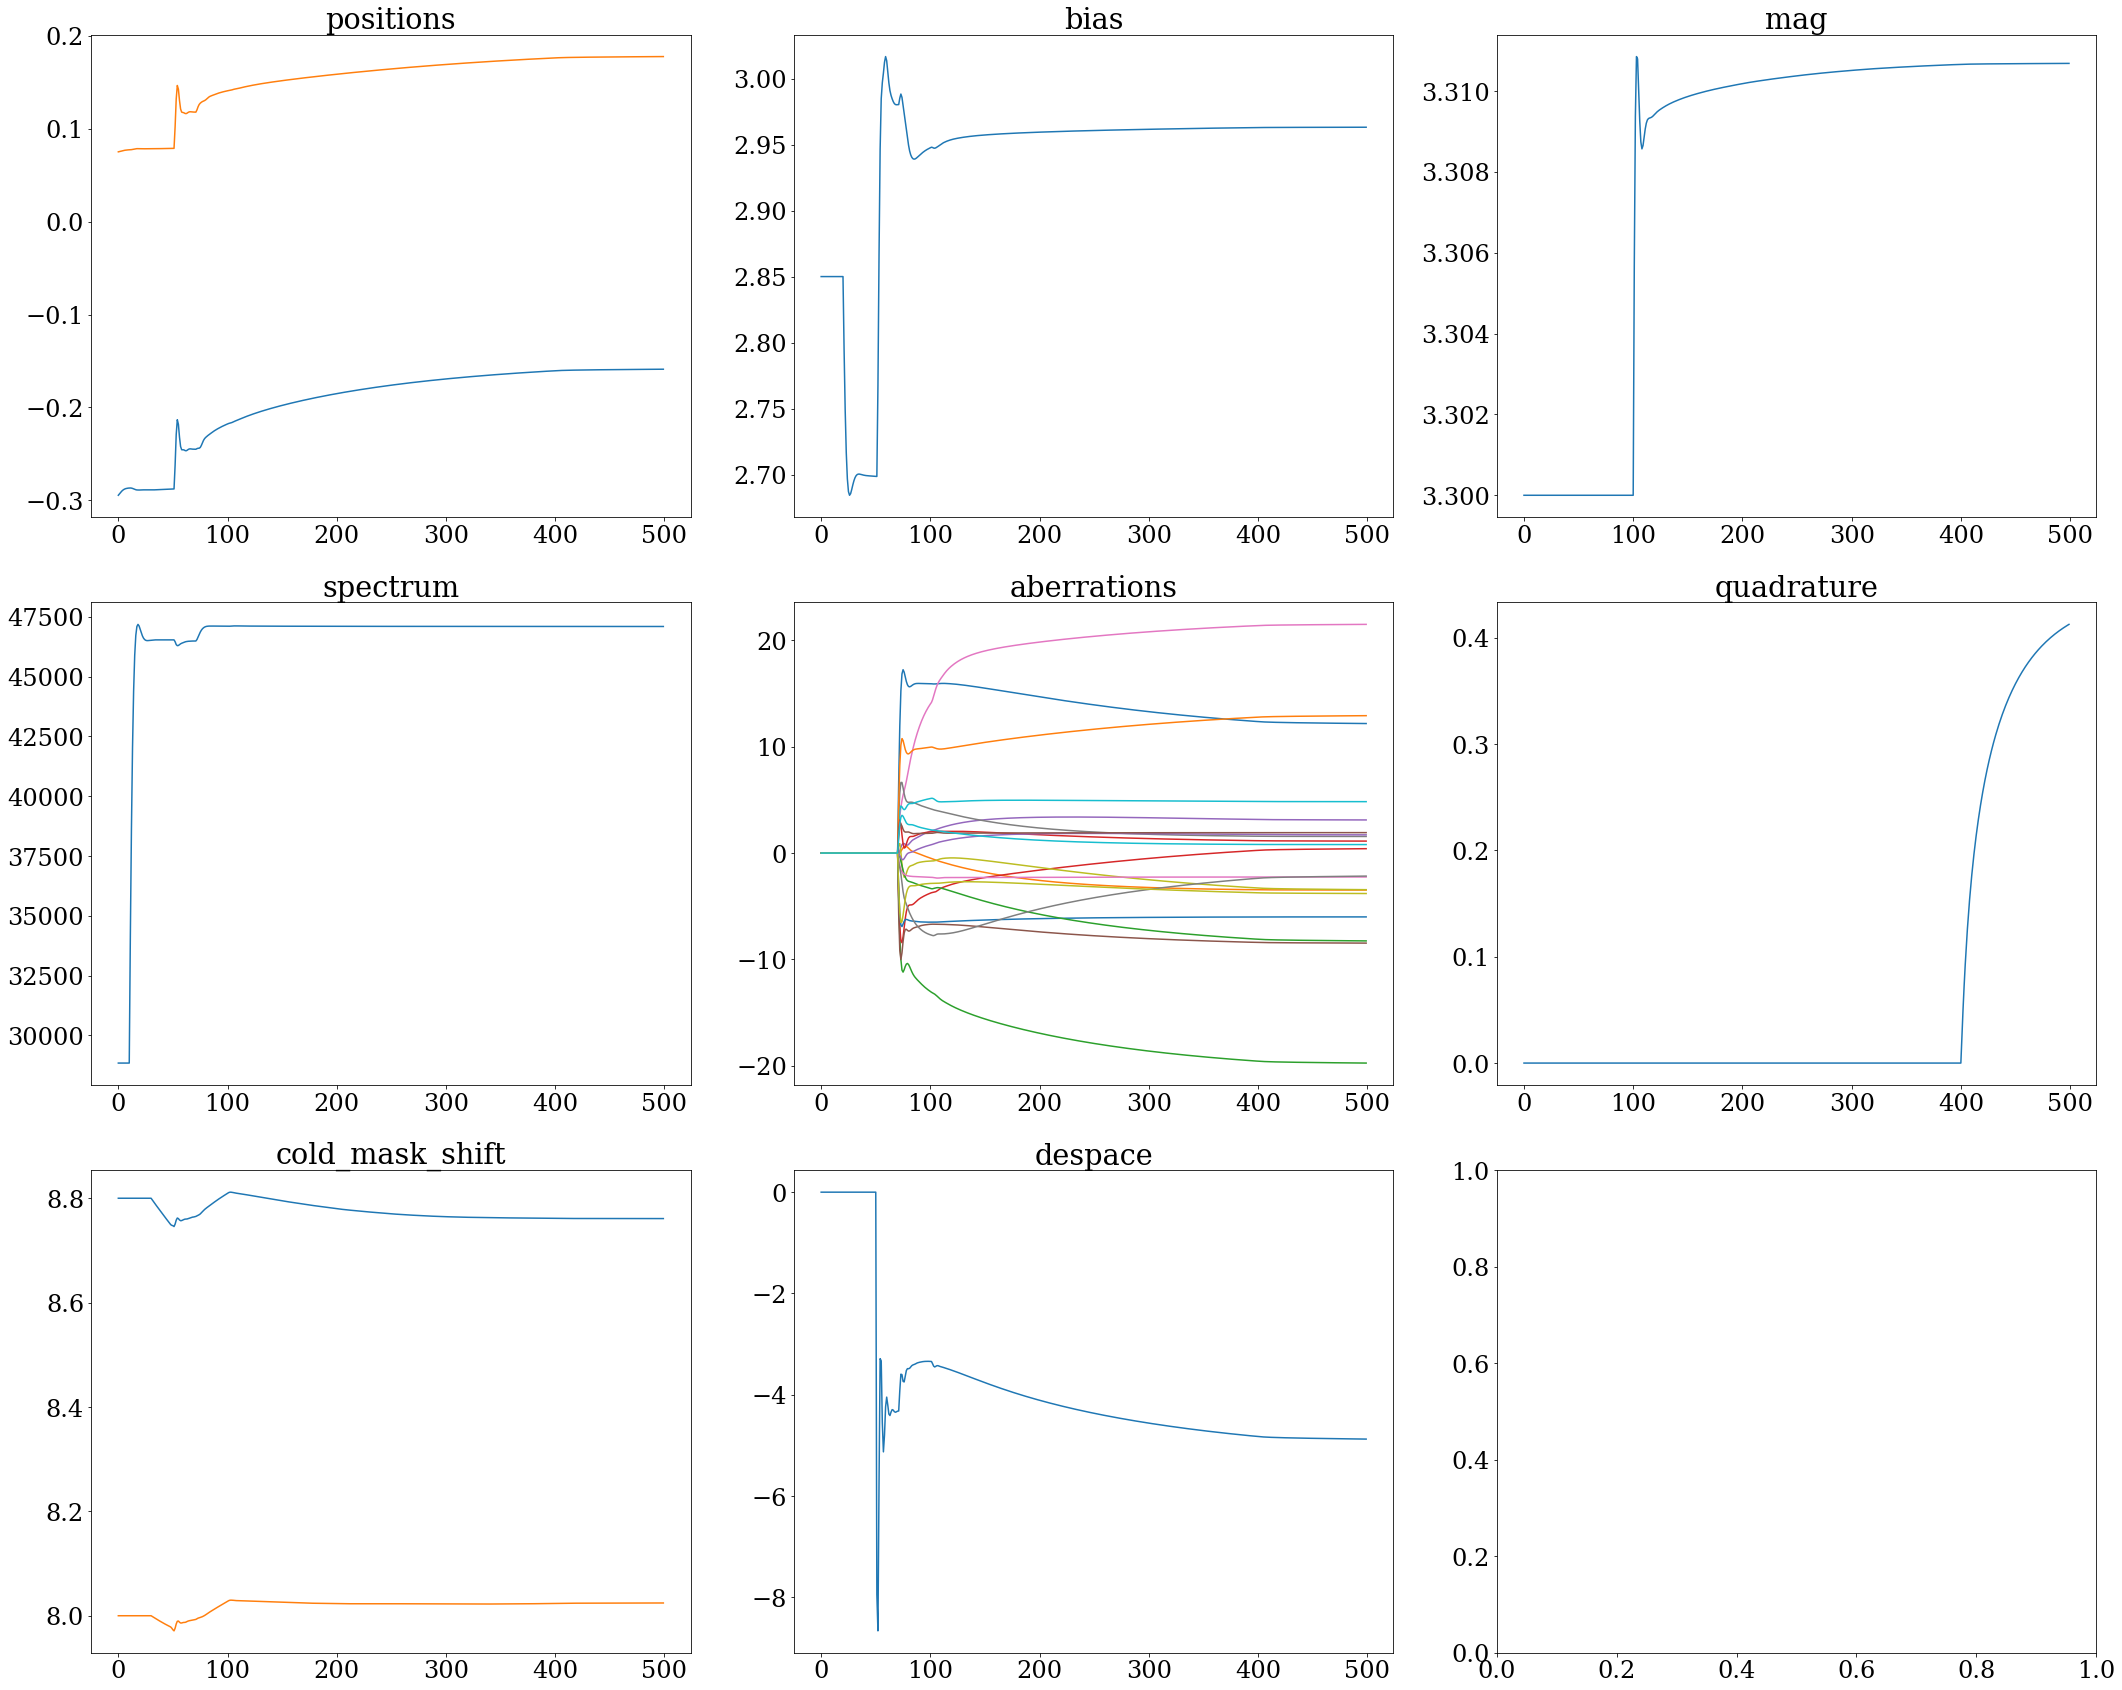

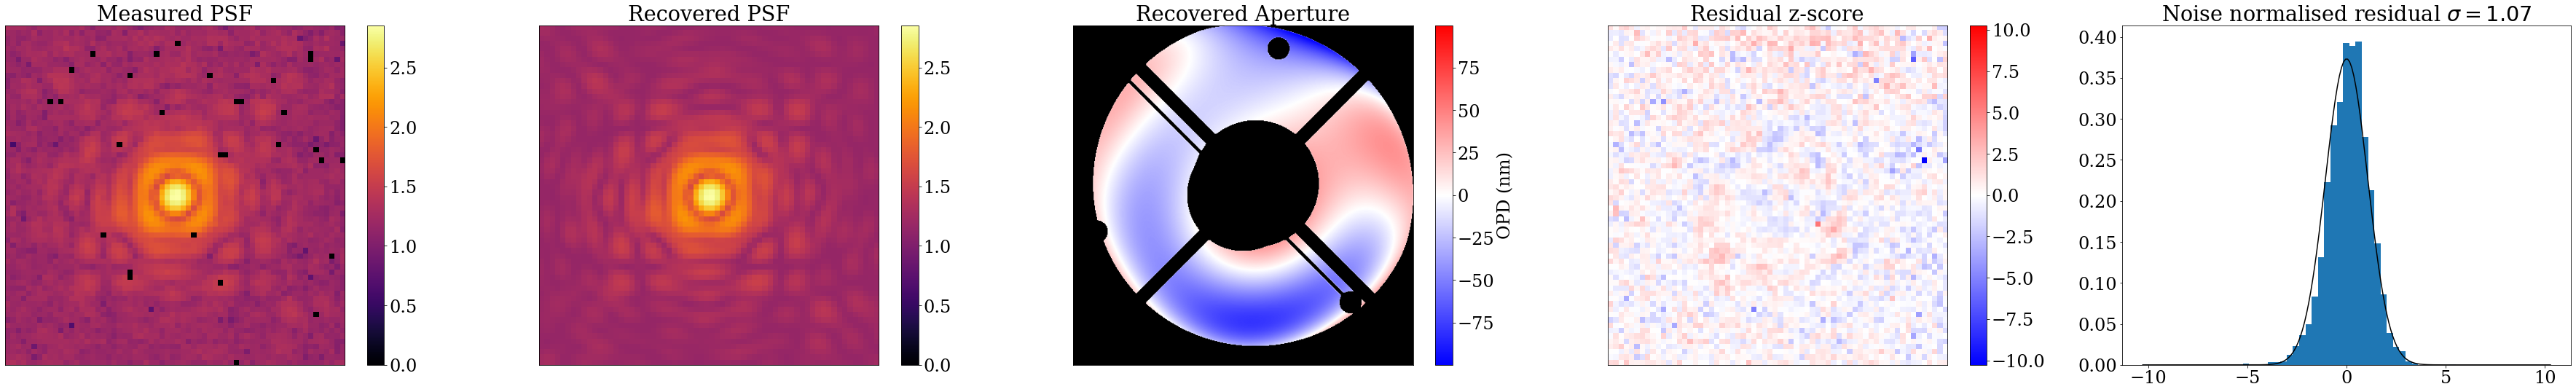

In [104]:
plot_params(params_history, groups, xw = 3)
plot_comparison(model_single, ModelParams(params_history[-1]), exposures_single, quadrature=True)

In [105]:
final_params = optimise_optimistix(params_history[-1], model_single, exposures_single)

0.9956496480848642


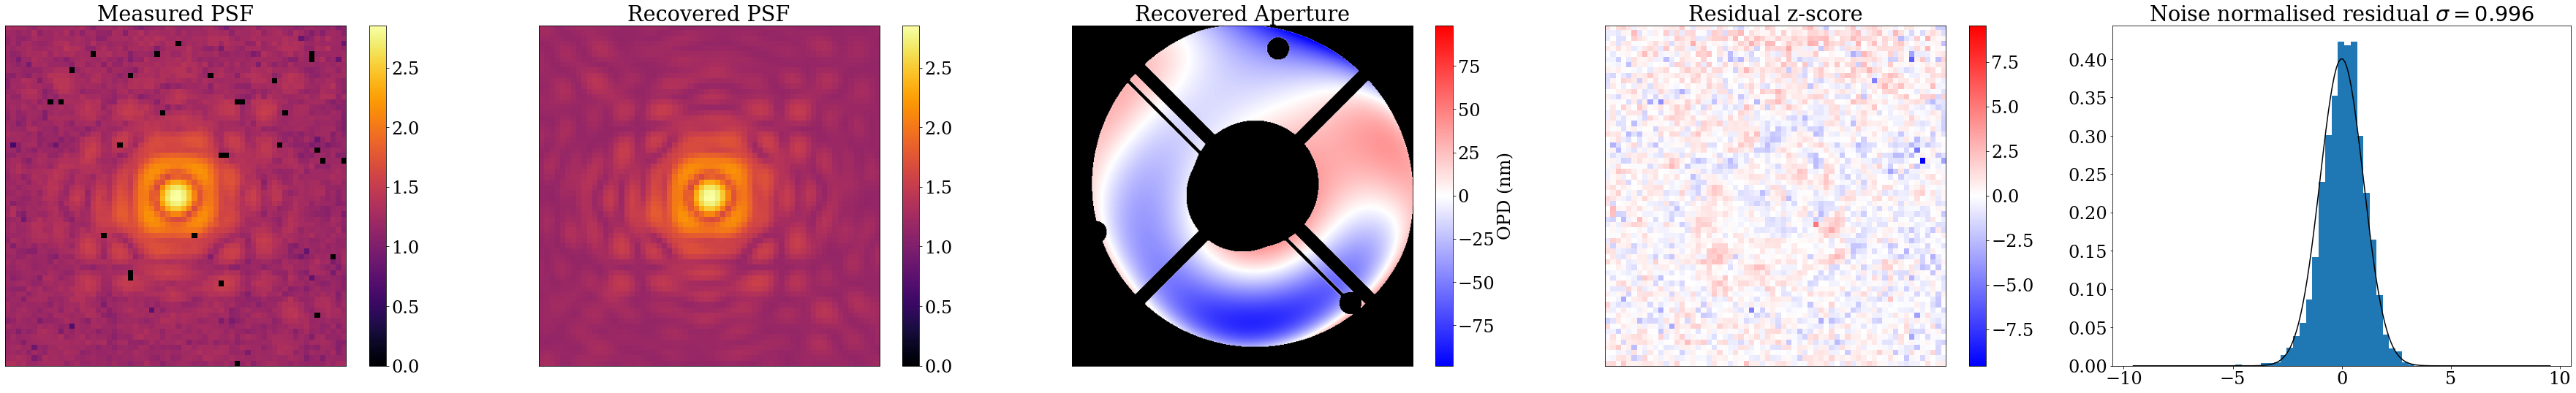

In [106]:
plot_comparison(final_params.inject((model_single)), final_params, exposures_single, quadrature=True)

In [107]:
final_params.params

{'aberrations': {'na2m01k7q': Array([ 10.80592569,  -3.56189739, -21.02404521,   1.60201261,
           2.7506663 ,  -8.8941096 ,  22.33104092,   1.50154971,
          -4.59856374,   4.74998953,  -5.98768841,  13.96721482,
          -9.37737682,   0.88921079,   1.50538302,   1.9322937 ,
          -2.23730717,  -0.68056791,  -4.30902714,   0.79338159],      dtype=float64)},
 'bias': {'na2m01k7q': Array(2.96522325, dtype=float64)},
 'cold_mask_shift': {'global': Array([8.76863709, 8.03028055], dtype=float64)},
 'despace': {'na2m01k7q': Array(-5.25164601, dtype=float64)},
 'mag': Array(3.31079967, dtype=float64),
 'positions': {'na2m01k7q': Array([-0.14721818,  0.18864896], dtype=float64)},
 'quadrature': {'na2m01k7q': Array(0.4435265, dtype=float64)},
 'spectrum': {'na2m01k7q': Array(47090.48186386, dtype=float64)}}

In [108]:
numpy.savez("test.npz", params=final_params.params)

In [109]:
f = lambda params: loss_fn(ModelParams(params), exposures_single, final_params.inject((model_single)))
F, unflatten = zdx.batching.hessian(f, final_params, nbatches=5*len(exposures_single))


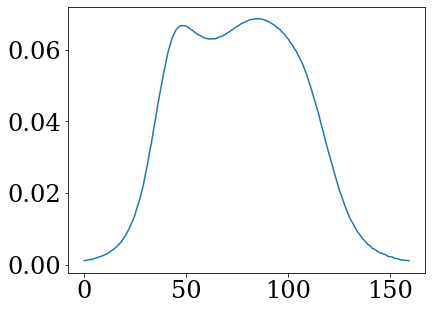

In [110]:
plt.plot(get_filter("../data/HST_NICMOS1.F166N.dat")[:,1][60:220])

In [111]:
unflatten(np.sqrt(np.diag(np.linalg.inv(F)))).params

{'aberrations': {'na2m01k7q': Array([1.78186375, 1.44879306, 1.52616702, 1.509075  , 1.09269589,
         1.07613054, 1.56996969, 1.33739025, 1.59809161, 0.78822203,
         0.68262597, 1.39327512, 1.39642882, 0.77984183, 0.79530666,
         0.57310137, 0.560854  , 2.00063379, 1.02672974, 0.85244211],      dtype=float64)},
 'bias': {'na2m01k7q': Array(0.03211667, dtype=float64)},
 'cold_mask_shift': {'global': Array([0.10911743, 0.11101921], dtype=float64)},
 'despace': {'na2m01k7q': Array(0.44967403, dtype=float64)},
 'mag': Array(0.00161065, dtype=float64),
 'positions': {'na2m01k7q': Array([0.01352617, 0.01330389], dtype=float64)},
 'quadrature': {'na2m01k7q': Array(0.00481009, dtype=float64)},
 'spectrum': {'na2m01k7q': Array(83.98591603, dtype=float64)}}